# Alfvén Modes

Problema molt semblant al de una corda amb estructura longitudinal

2025-06-17 17:06:03,721 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 17s, Remaining: 0s, Rate: 5.9e-02/s
evals.size (before)  258
evals.size (after removing inf)  254
evals.size (after removing < 0)  253

evals size 253
true_evals size  253
First 5 Eigenvalues (sqrt): [ 12.51424657  44.47756988  56.55204808  66.61843819 103.28889934]
First 5 True eigenvalues: [ 13.17871403  47.09448986  56.73683053  75.65754801 105.51276705]
Relative error (resta norm.): [0.05041975 0.05556743 0.00325683 0.119474   0.02107676]


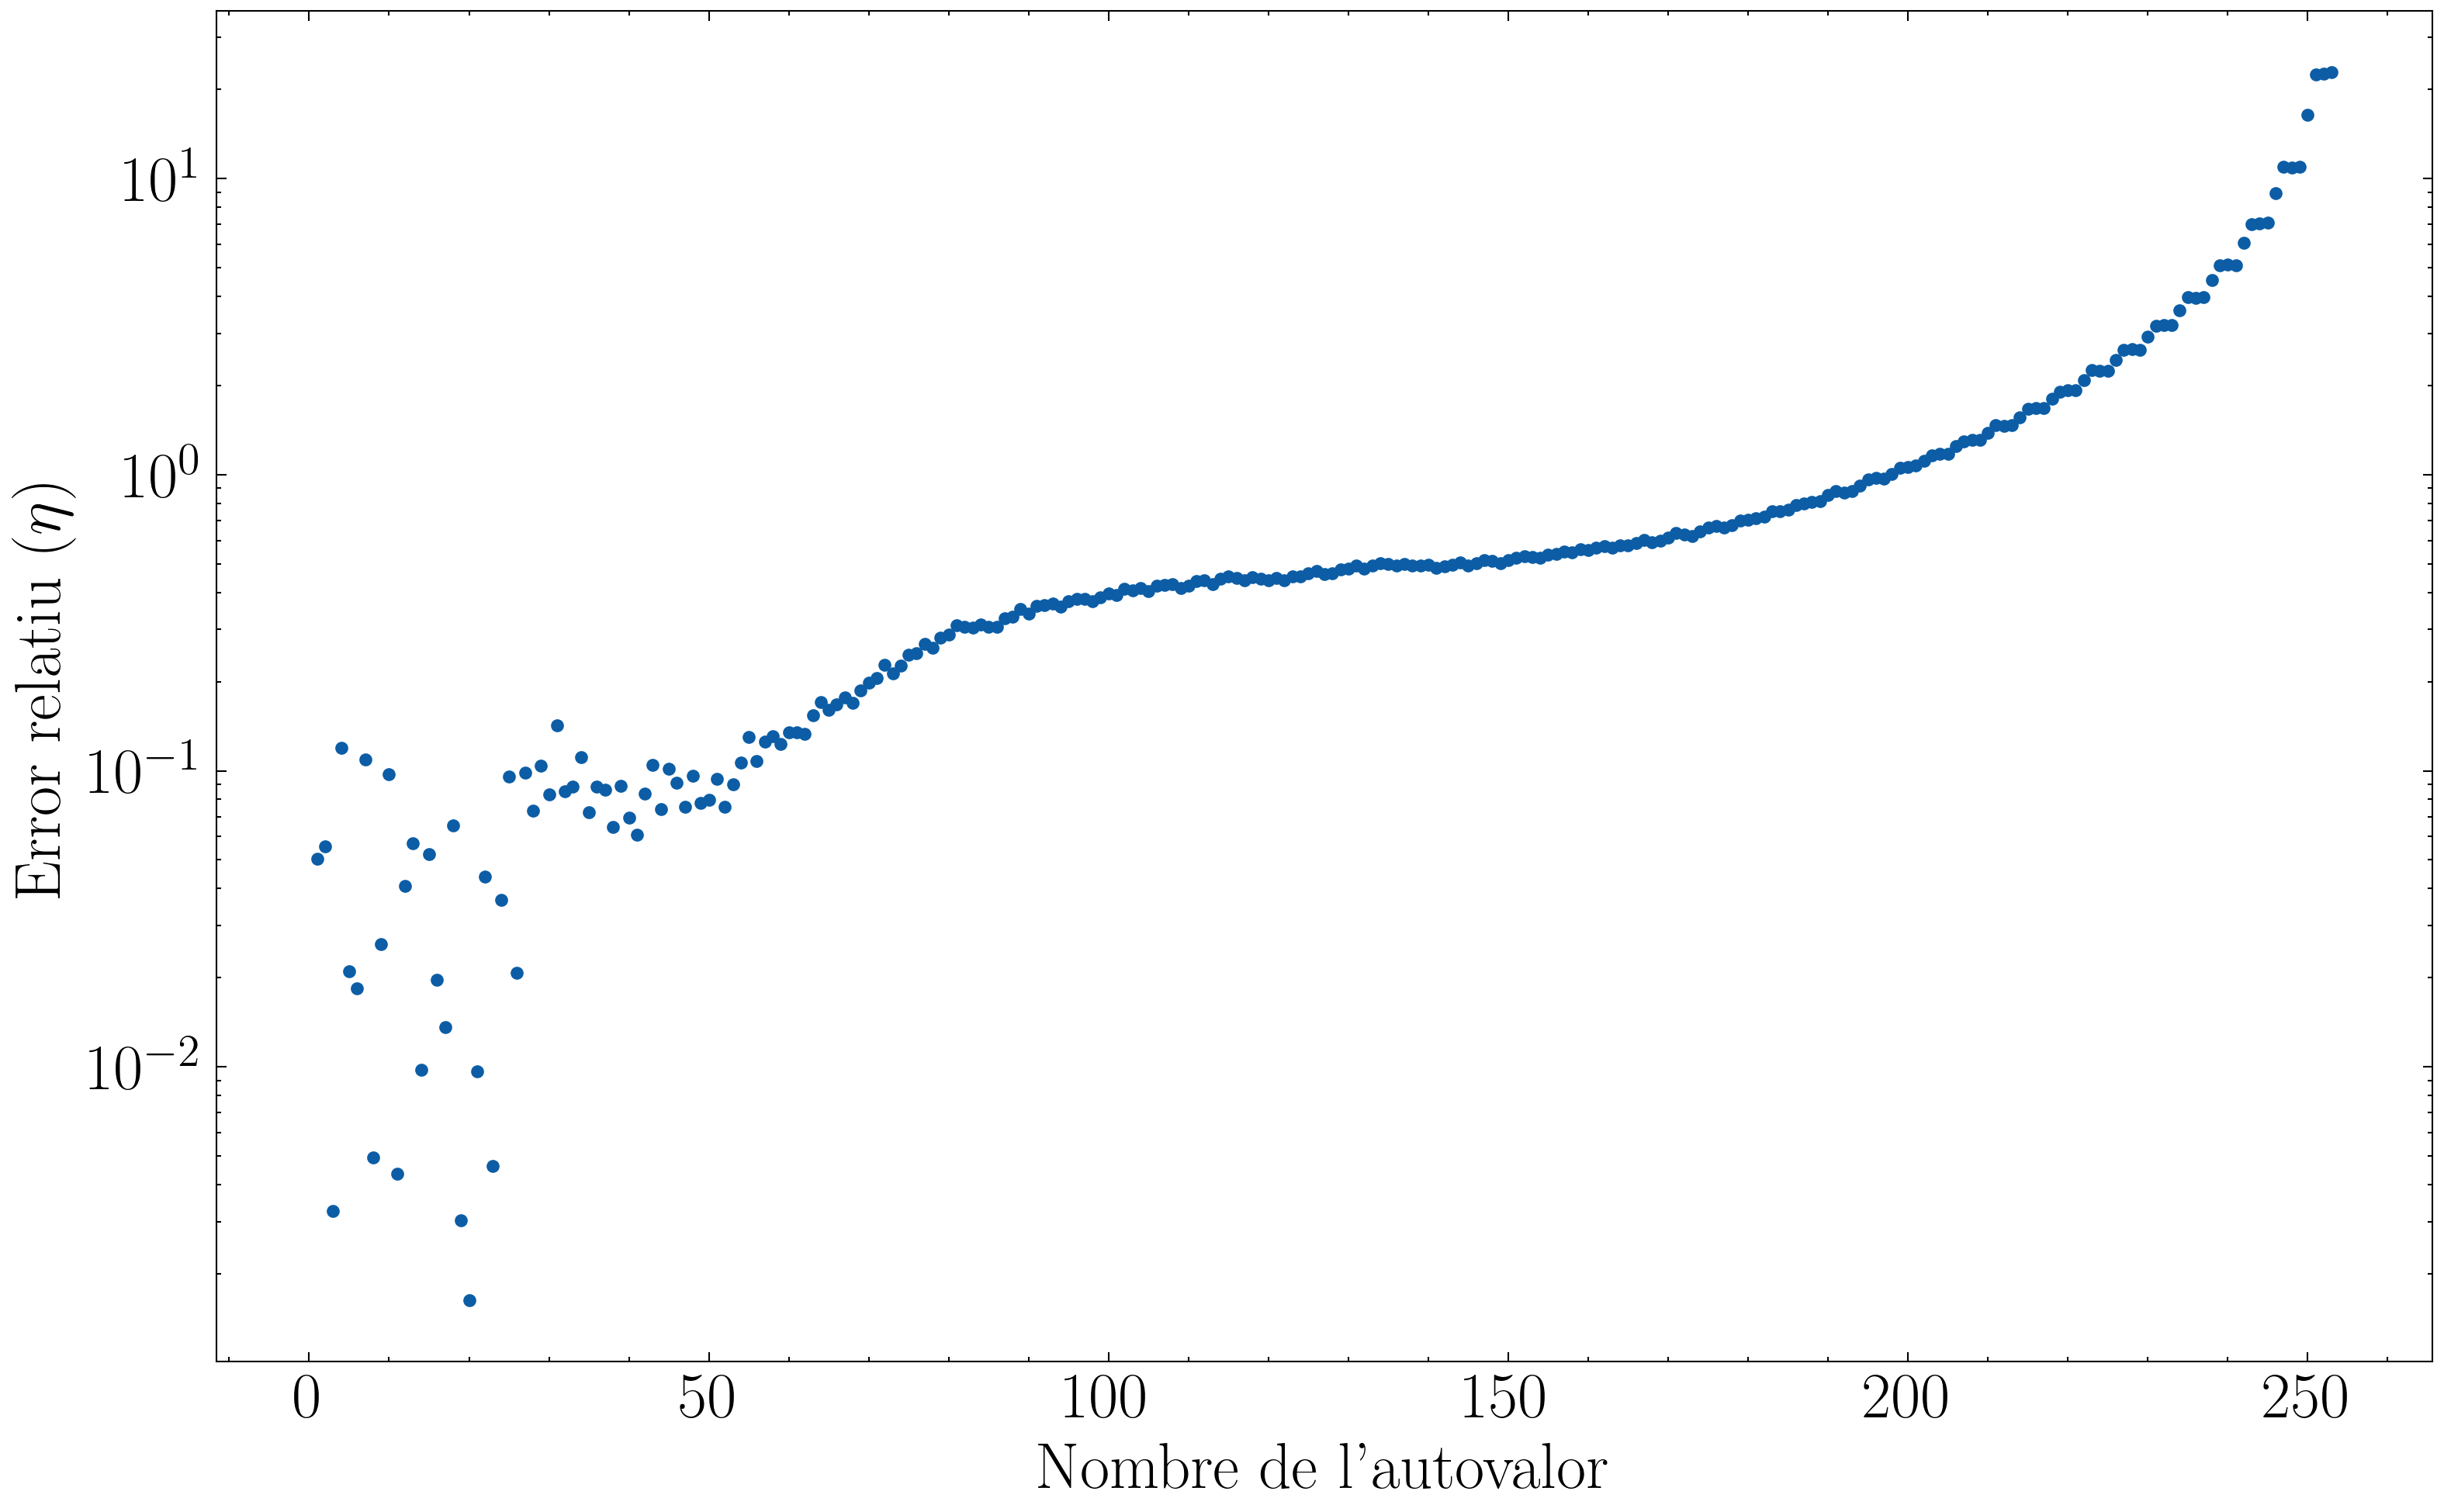

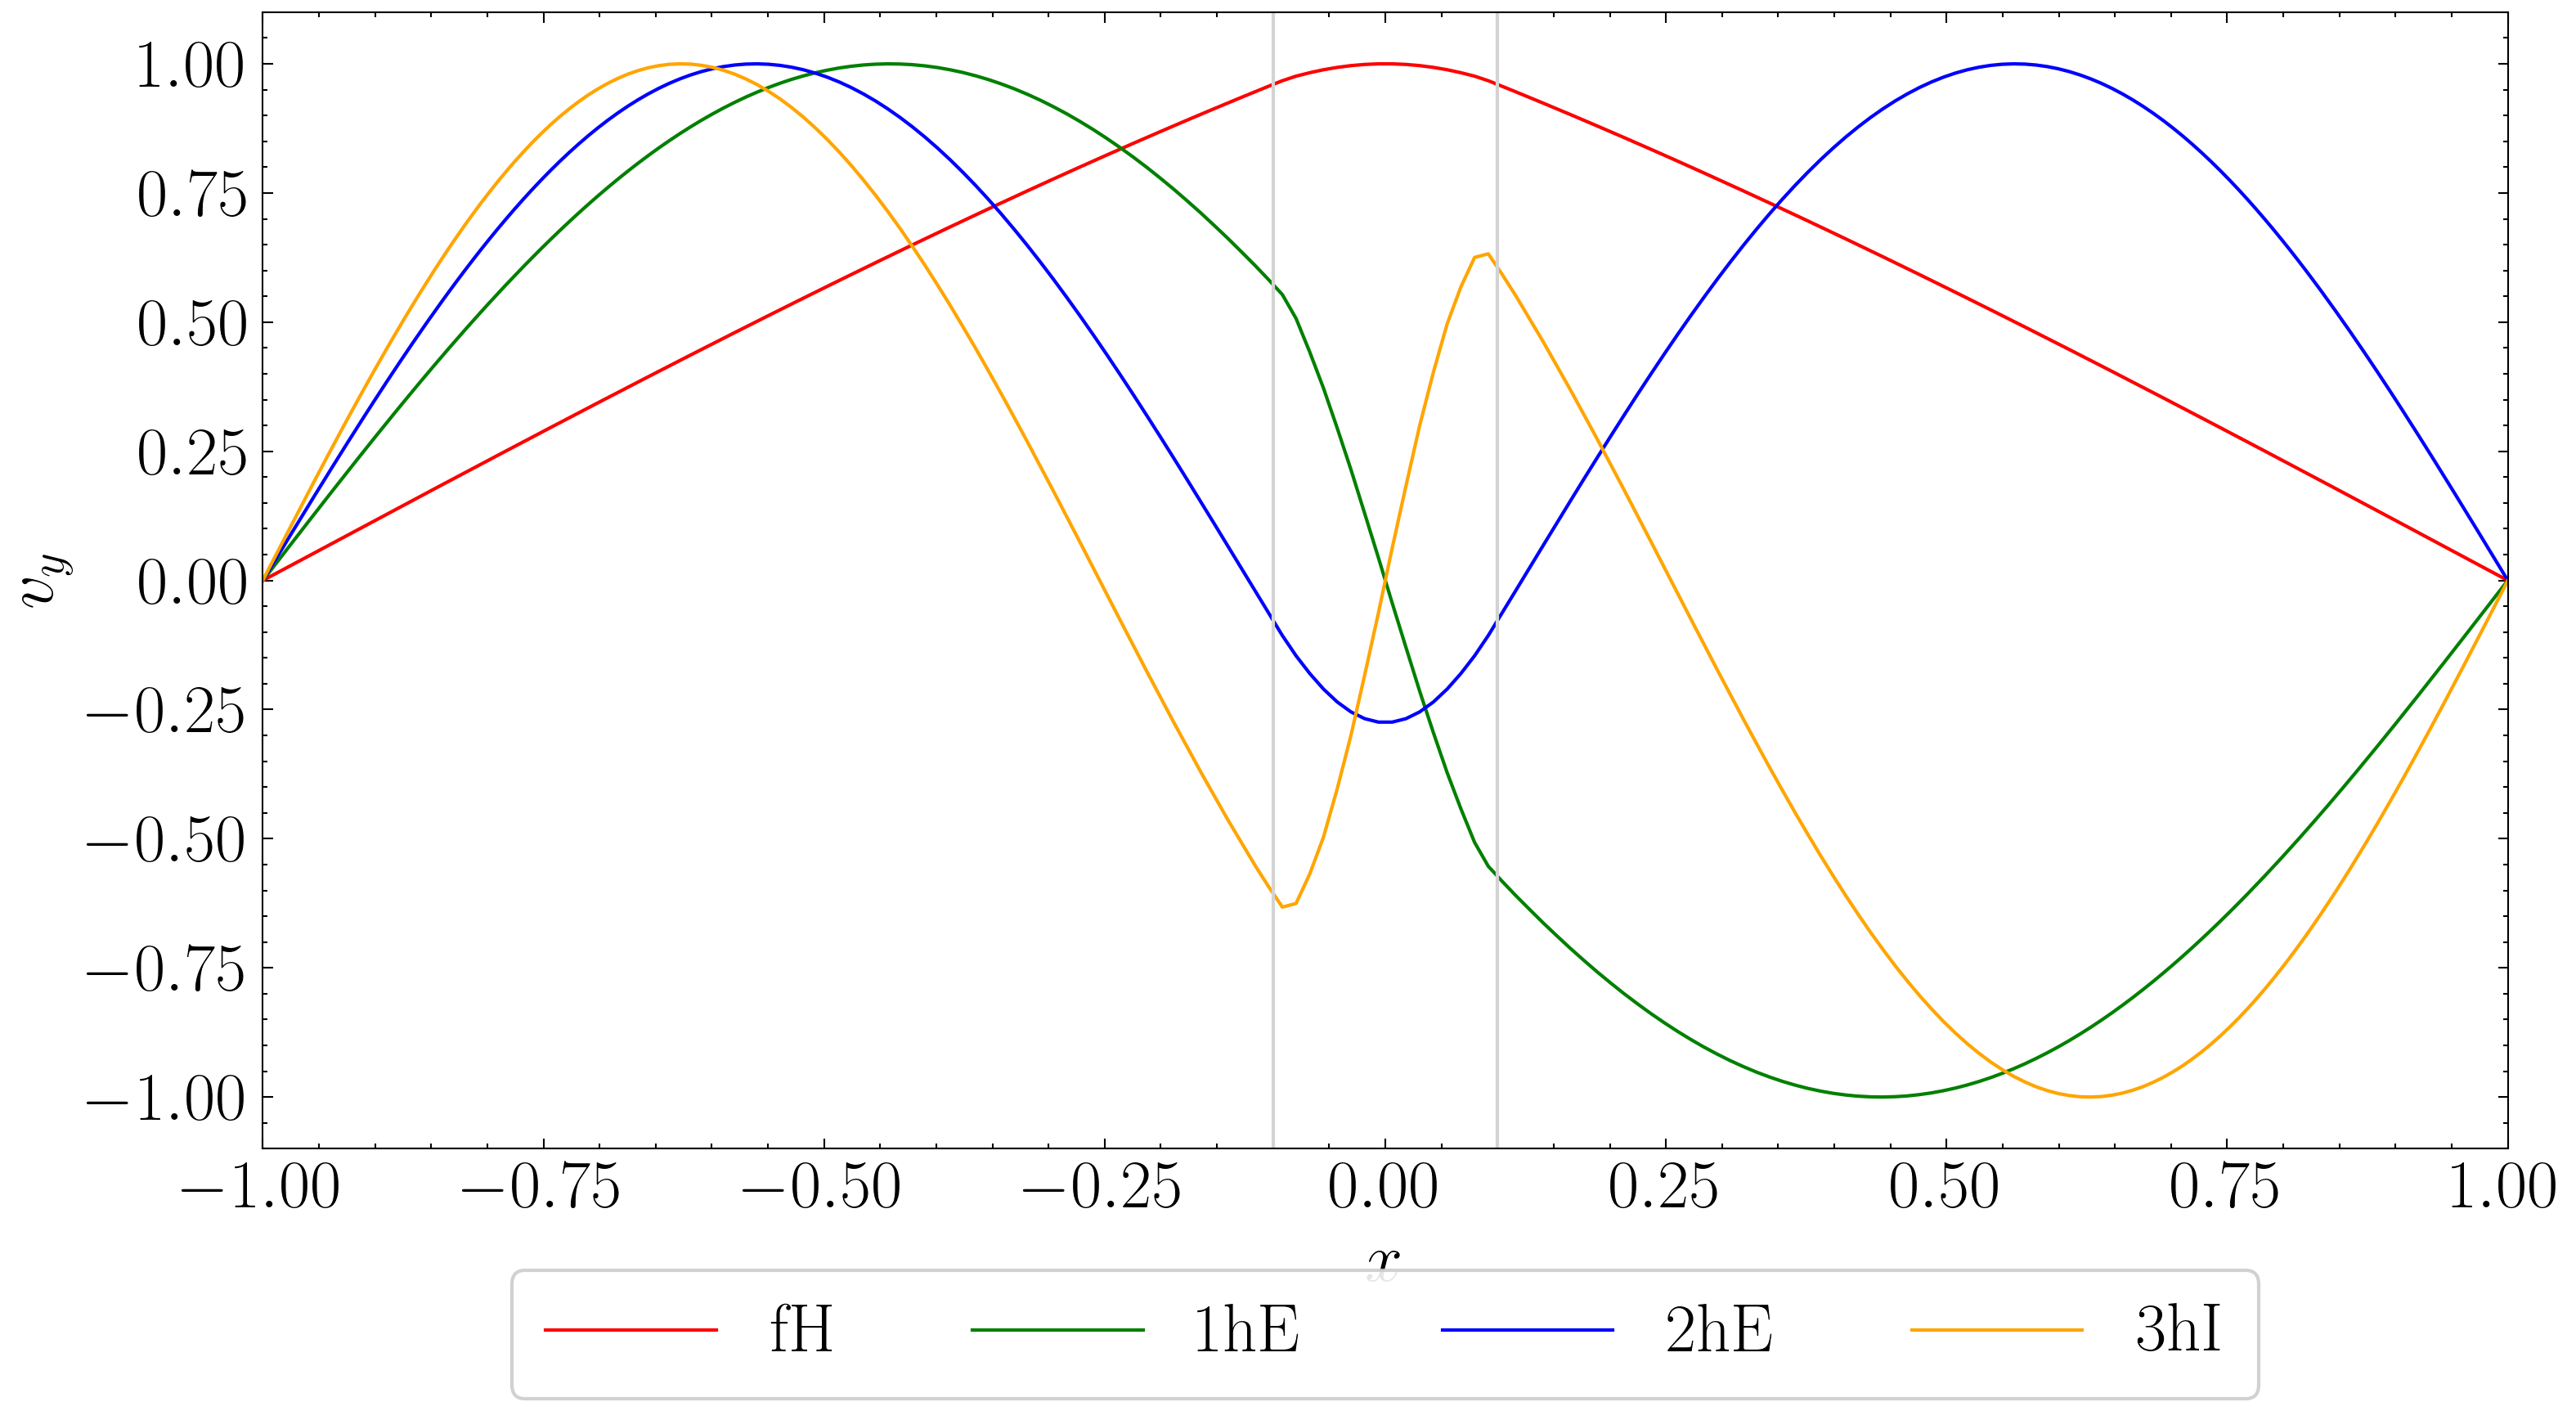

' Plot imag part of v10y\nplt.figure(figsize=(10, 6))\nx = dist.local_grid(xbasis)\n##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")\nfor n, idx in enumerate(np.argsort(solver.eigenvalues)[:4], start=1):\n    solver.set_state(idx, solver.subsystems[0])\n    ##if solver.eigenvalues[idx].real > 0:\n    ##    print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")\n\n    # ens interessa part Im per comprovar que està bé; ha de ser nul·la\n    vg = (v[\'g\'] / v[\'g\'][1]).real\n    vi = (v[\'g\'] / v[\'g\'][1]).imag\n    plt.plot(x, vi/np.max(np.abs(vg)), label=f"n={n}") # no normalitzam pq ens divideix per 0 ### ara sí normalitzam\nplt.xlim(xmin, xmax)\nplt.legend(loc="lower right", frameon=True)\nplt.ylabel(r"Mode structure")\nplt.xlabel(r"x")\nplt.title(r"Imaginary part of $v_{y}$")\nplt.tight_layout()\n#plt.savefig("Im_A_eigenvectors.pdf")\n#plt.savefig("Im_A_eigenvectors.png", dpi=200)\n'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from scipy.optimize import fsolve
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,           # Match LaTeX body text (12pt)
    #"font.weight": "bold",     # Match LaTeX body text (bold)
    "axes.titlesize": 20,      # Title font size
    "axes.labelsize": 20,      # Axis label font size
    #"axes.labelweight": "bold",# Axis label weight
    "xtick.labelsize": 20,     # X tick label font size
    "ytick.labelsize": 20,     # Y tick label font size
    "legend.fontsize": 20,     # Legend font size
    "figure.dpi": 300,         # High DPI for sharpness
    #"font.family": "serif",    # Optional: match LaTeX font
    "mathtext.fontset": "cm",  # Optional: Computer Modern math
    "text.usetex": True,                # Use LaTeX for all text
    #"font.serif": ["Computer Modern"],  # Use Computer Modern (LaTeX default)
})



""" Funcions per calcular els autovalors exactes """
# Funcions den Monxo per calcular els autovalors exactes d'una corda amb densitat variable.
def dispersion_relation(omega):
    disprel_even = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2))
    disprel_odd = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2))
    disprel = disprel_even * disprel_odd
    return disprel

def get_eigenvalues(Nevals):
    Nsol = 0
    omega0 = 1
    omega_step = 0.5
    exact_soln = np.array([])
    while Nsol < Nevals:
        sol = fsolve(dispersion_relation, omega0)
#         print('omega0, sol ', omega0, sol)
        if sol > 0:
            exact_soln = np.append(exact_soln, sol)
            exact_soln = np.unique(exact_soln.round(decimals=8))
#         print('exact_soln, exact_soln**2 ', exact_soln, exact_soln**2)
#         print(exact_soln.size)
        Nsol = exact_soln.size
        omega0 = omega0 + omega_step
#    print('exact_soln', exact_soln[0:5])
#    print('exact_soln**2 ', exact_soln**2)
    print()
    return exact_soln



""" Paràmetres """
Nx = 128*2 # amb 32 ja no és smooth...
dtype = np.complex128 # malla en la que es treballa: 128 complexes, ja que hem definit Nx = 128



""" Límits del domini """
xmax = 1
xmin = -1 # = -xmax
xp = 0.1
# xc ∈ [-1, -0.1], xc ∈ [0.1, 1]

# Square of the wave velocity in the two parts of the system.
vAp2 = 20  # 1 # 9  # velocitat dedins menor que defora
vAc2 = 250 # 6 # 36



""" Bases """
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=dtype)
xbasis = d3.Legendre(xcoord, size=Nx, bounds=(xmin, xmax)) # Definim una base amb uns altres límits. Chebyshev menos error?



""" Camps """
### Velocitats ###
v = dist.Field(name='v', bases=xbasis) # v = field of the wave function: v10y
# Definesc la velocitat com en oceano: (u,v,w) per no liar subíndexos i derivades.

### Espai real ###
x = dist.local_grid(xbasis) # punts del domini

### Constants ###
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.
#kz = dist.Field(name='kz', bases=xbasis) # kz = Wave number in the z direction
#kz['g'] = 0 # Representa el nombre d'ona en la direcció z en l'espai real ('g').
#kz['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [0, 0, 0]) # Representa el nombre d'ona en la direcció z en l'espai real ('g') a trossos.

### Autovalors ###
s = dist.Field(name='s') # AUTOVALOR ω^2 = s

### Auxiliars de les derivades ###
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')



""" Substitucions """
### Derivades espacials ###
dx = lambda A: d3.Differentiate(A, xcoord) # Derivative operator
lift_basis = xbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)
vx = dx(v) + lift(tau_1) # First-order reduction of the velocity in the y direction
vxx = dx(vx) + lift(tau_2) # Second-order reduction of the velocity in the y direction
# No és convenient posar directament dx(v) a l'equació ja que faltaria el lift... s'ha de definir bé la derivada
# No definim derivada temporal ja que és un EVP!!!



""" Problem """
# 1 equació i 1 incògnita
problem = d3.EVP([v, tau_1, tau_2], eigenvalue=s, namespace=locals())

# Problema d'ones d'Alfvén ~ corda guitarra amb densitat variable
problem.add_equation("s * v  +  vA2 * vxx  =  0") # (18')
problem.add_equation("v(x=xmin) = 0")
problem.add_equation("v(x=xmax) = 0")



""" Solve """
solver = problem.build_solver()
# print(solver.subproblems)
solver.solve_dense(solver.subproblems[0])
evals = np.sort(solver.eigenvalues)

print('evals.size (before) ', evals.size)
evals = evals[~np.isinf(evals)]                      # eliminam els infinits; el ~ és un operador bitwise NOT, que retorna True si el valor és False i viceversa
print('evals.size (after removing inf) ', evals.size)
evals = evals[evals > 0]                             # eliminam els valors negatius
print('evals.size (after removing < 0) ', evals.size)
evals = np.sqrt(evals)

# Autovalors exactes
Nevals = np.rint(Nx*1.2).astype(int)
exact_soln = get_eigenvalues(Nevals)
n = 1 + np.arange(evals.size)
# true_evals = (n * np.pi / 2*xmax)**2               # vàlid per vA2 constant
true_evals = exact_soln[0:evals.size]

print('evals size', evals.size)
#print("Evals", evals)
print("true_evals size ", true_evals.size)
#print("True Evals", true_evals)

relative_error = np.abs(evals - true_evals) / true_evals

# Agafam la part real per fer un print més net
evals = evals.real
print("First 5 Eigenvalues (sqrt):", evals[:5])
print("First 5 True eigenvalues:", true_evals[:5])
print("Relative error (resta norm.):", relative_error[:5])



""" Plot """
### Plot error ###
plt.figure(figsize=(11, 7))
plt.semilogy(n, relative_error, '.')
plt.xlabel("Nombre de l'autovalor")
plt.ylabel(fr"Error relatiu $(\eta)$")
#plt.title("Eigenvalue error")
plt.tight_layout()
#plt.savefig("eigenvalue_error_vA.png", dpi=300, bbox_inches='tight')
plt.show()


### Define colors for the lines ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

### Define mode labels ###
mode_labels = ['fH', '1hE', '2hE', '3hI' ,'4hE']

### Eigenvalues to plot ###
N_min_modes = 1
N_max_modes = 5

### Plot real part of v10y ###
plt.figure(figsize=(11, 7))
x = dist.local_grid(xbasis)
lines = []
labels = []
##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_modes:N_max_modes], start=1):
   ##if solver.eigenvalues[idx].real > 0:
   ##     print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")

   solver.set_state(idx, solver.subsystems[0])
   vg = (v['g']).real / (v['g'][1]).real
   label = f"{mode_labels[n-1]}" if n-1 < len(mode_labels) else f"n = {n}"
   line, = plt.plot(x, vg/np.max(np.abs(vg)), label=label, color=colors[n-1])
   lines.append(line)
   labels.append(label)
   
plt.xlim(xmin, xmax)
plt.ylabel(r"${v}_{y}$")
plt.xlabel(r"$x$")
#plt.title(r"Part real de $v_{y}$")
yticks = np.arange(-1.0, 1.25, 0.25)
plt.yticks(yticks)
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

plt.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),# Centered, just below the x axis
    ncol=len(lines),            # One column per mode for a wide legend
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=2.5,
    handleheight=0.5,
    borderpad=0.5,
    borderaxespad=0.5,
    labelspacing=0.1,
    framealpha=0.9
)

#plt.savefig("modes_Alfven.png", dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

""" Plot imag part of v10y
plt.figure(figsize=(10, 6))
x = dist.local_grid(xbasis)
##print("Eigenvalues whose eigenfunctions are plotted, real and imaginary parts")
for n, idx in enumerate(np.argsort(solver.eigenvalues)[:4], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ##if solver.eigenvalues[idx].real > 0:
    ##    print(f"{idx:04d}    {solver.eigenvalues[idx].real:+.2e}    {solver.eigenvalues[idx].imag:+.2e}")

    # ens interessa part Im per comprovar que està bé; ha de ser nul·la
    vg = (v['g'] / v['g'][1]).real
    vi = (v['g'] / v['g'][1]).imag
    plt.plot(x, vi/np.max(np.abs(vg)), label=f"n={n}") # no normalitzam pq ens divideix per 0 ### ara sí normalitzam
plt.xlim(xmin, xmax)
plt.legend(loc="lower right", frameon=True)
plt.ylabel(r"Mode structure")
plt.xlabel(r"x")
plt.title(r"Imaginary part of $v_{y}$")
plt.tight_layout()
#plt.savefig("Im_A_eigenvectors.pdf")
#plt.savefig("Im_A_eigenvectors.png", dpi=200)
"""

# A l'hora de representar la part real de les autofuncions has de tenir clar que la velocitat v (v10y) és en la direcció y i és real.
# A més, el que es representa és la velocitat, no la corda en sí. Llavors un node implica velocitat nul·la: aquell punt no es mou.
# Els màxims i mínims són els punts on la velocitat és màxima absolutament, no és que la corda es deformi amb aquella forma...


In [ ]:
# Modes interns i externs per veurer-ho més clar; també el 1r de cada és híbrid!